In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transforms
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64)

# Load pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Train only final layer
for epoch in range(3):
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("Training done")


100%|██████████| 170M/170M [00:10<00:00, 16.4MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 114MB/s]


Training done


In [9]:
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [2]:
classes = trainset.classes

images, labels = next(iter(testloader))
images = images.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

print("Predicted:", classes[preds[0]])


Predicted: cat


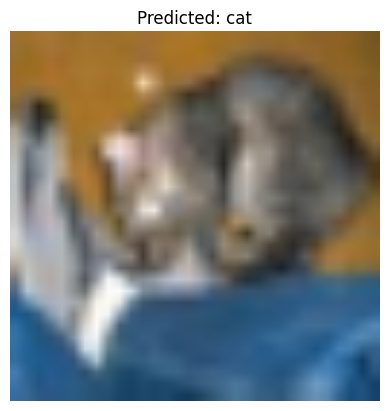

In [10]:
import matplotlib.pyplot as plt

img = images[0].cpu()
plt.imshow(img.permute(1,2,0))
plt.title(f"Predicted: {classes[preds[0]]}")
plt.axis('off')
plt.show()


In [11]:
print("True:", classes[labels[0]])
print("Pred:", classes[preds[0]])


True: cat
Pred: cat


### Problem 2


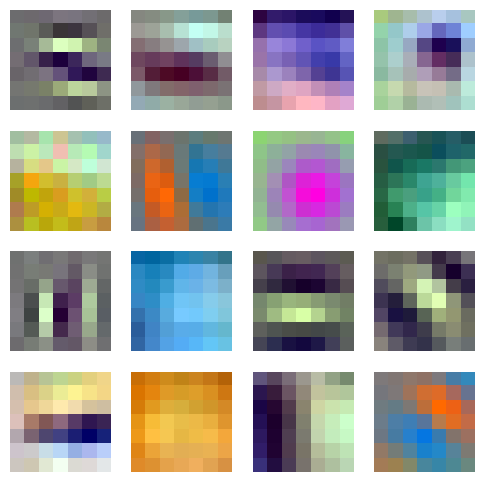

In [3]:
filters = model.conv1.weight.data.cpu()

fig, axes = plt.subplots(4,4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    f = filters[i]
    f = (f - f.min())/(f.max()-f.min())
    ax.imshow(f.permute(1,2,0))
    ax.axis('off')

plt.show()


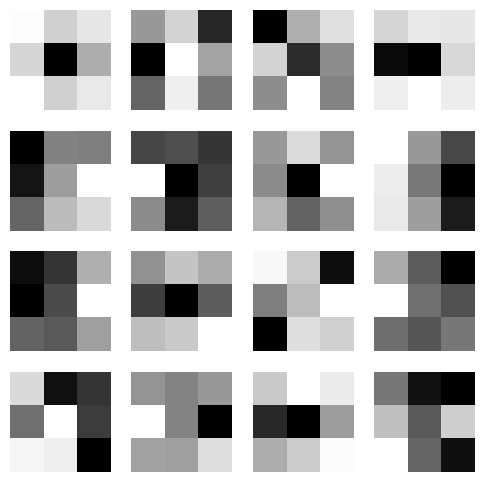

In [12]:
deep_filters = model.layer1[0].conv1.weight.data.cpu()

fig, axes = plt.subplots(4,4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    f = deep_filters[i,0]   # show one channel
    f = (f - f.min())/(f.max()-f.min())
    ax.imshow(f, cmap='gray')
    ax.axis('off')

plt.show()


### Problem 3

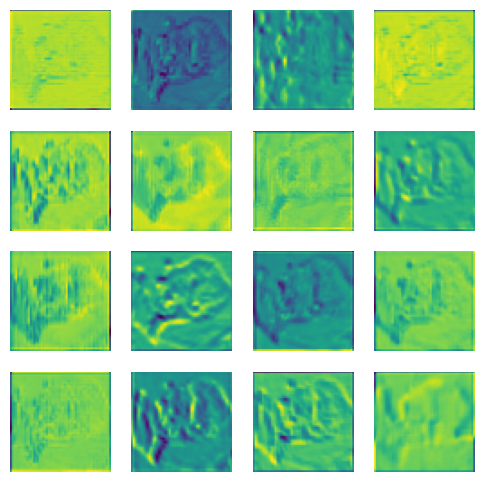

In [4]:
feature_maps = []

def hook_fn(module, input, output):
    feature_maps.append(output)

layer = model.layer1[0].conv1
layer.register_forward_hook(hook_fn)

img, _ = testset[0]
input_img = img.unsqueeze(0).to(device)

model(input_img)

fm = feature_maps[0][0].cpu()

fig, axes = plt.subplots(4,4, figsize=(6,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(fm[i], cmap='viridis')
    ax.axis('off')

plt.show()


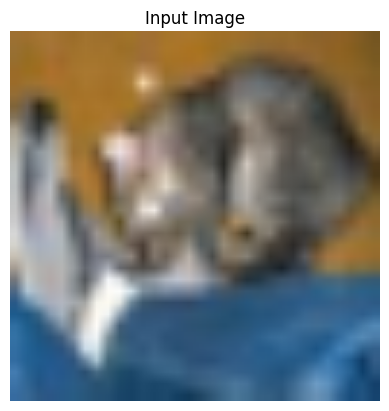

In [13]:
plt.imshow(img.permute(1,2,0))
plt.title("Input Image")
plt.axis('off')
plt.show()


### Problem 4

In [5]:
pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 33.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=b8960242ed2c6e86a252e14897e2d8d9ee8e26878fb1b45cc398478542a40d1e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


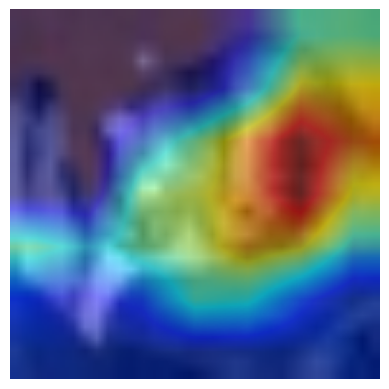

In [7]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

model.eval()

target_layers = [model.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

# prepare image properly
img, label = testset[0]

input_tensor = img.unsqueeze(0).to(device)

# IMPORTANT — requires grad
input_tensor.requires_grad = True

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_img = img.permute(1,2,0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(cam_image)
plt.axis('off')
plt.show()


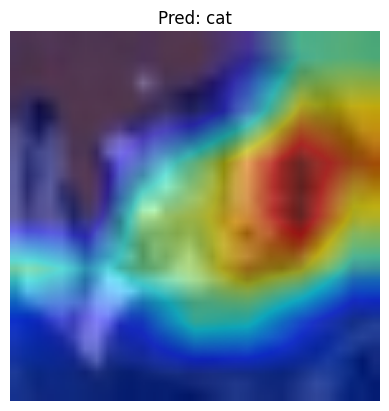

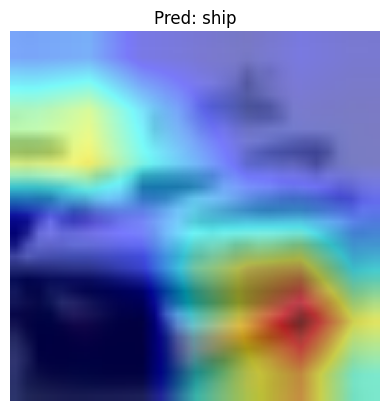

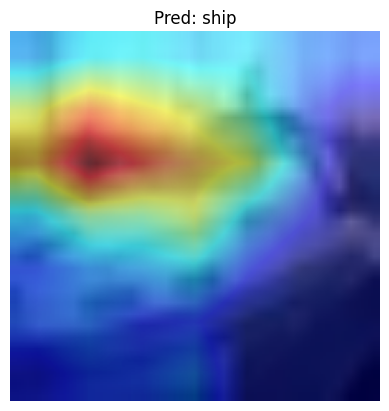

In [14]:
count = 0

for img, label in testset:
    input_tensor = img.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    output = model(input_tensor)
    pred = output.argmax().item()

    if pred == label:
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        rgb_img = img.permute(1,2,0).cpu().numpy()
        rgb_img = (rgb_img - rgb_img.min())/(rgb_img.max()-rgb_img.min())

        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        plt.imshow(cam_image)
        plt.title(f"Pred: {classes[pred]}")
        plt.axis('off')
        plt.show()

        count += 1
        if count == 3:
            break


### Problem 5

In [15]:
for img, label in testset:
    out = model(img.unsqueeze(0).to(device))
    if out.argmax() != label:
        wrong_img = img
        wrong_label = label
        wrong_pred = out.argmax().item()
        break


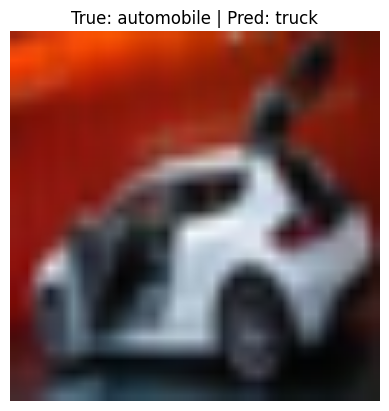

In [16]:
plt.imshow(wrong_img.permute(1,2,0))
plt.title(f"True: {classes[wrong_label]} | Pred: {classes[wrong_pred]}")
plt.axis('off')
plt.show()


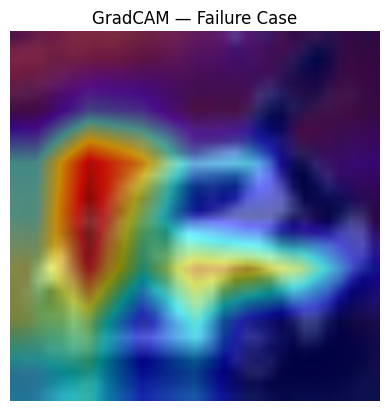

In [17]:
input_tensor = wrong_img.unsqueeze(0).to(device)
input_tensor.requires_grad = True

grayscale_cam = cam(input_tensor=input_tensor)[0]

rgb_img = wrong_img.permute(1,2,0).cpu().numpy()
rgb_img = (rgb_img - rgb_img.min())/(rgb_img.max()-rgb_img.min())

cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(cam_image)
plt.title("GradCAM — Failure Case")
plt.axis('off')
plt.show()
